# Coffee in Trend — Arabica vs Robusta Time Series (2013–2021)

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA_DIR = Path(".")          # folder containing the two CSV files
FIG_DIR = Path("figures")     # output folder for the PNG charts
FIG_DIR.mkdir(exist_ok=True)

YEAR_START, YEAR_END = 2013, 2021
SOURCE_NOTE = ("Source: Office of Agricultural Economics (OAE), Agricultural Statistics of Thailand 2021, "
               "Table 62 (Coffee Arabica) and Table 63 (Coffee Robusta).")

## 1. Load and combine the data

In [2]:
arabica = pd.read_csv(DATA_DIR / "table62_coffee_arabica.csv")
robusta = pd.read_csv(DATA_DIR / "table63_coffee_robusta.csv")

arabica["variety"] = "Arabica"
robusta["variety"] = "Robusta"

coffee = pd.concat([arabica, robusta], ignore_index=True)

# Keep 2013-2021 only and drop forecast rows (forecast_flag == "f")
coffee = coffee[
    coffee["year_ce"].between(YEAR_START, YEAR_END)
    & (coffee["forecast_flag"].fillna("") != "f")
].copy()

coffee.head()

,year_be,year_ce,planted_area_1000_rai,harvested_area_1000_rai,production_tons,yield_kg_per_rai,farm_gate_price_baht_per_kg,value_of_production_million_baht,forecast_flag,variety
0,2556,2013,72,49,7569,155,110.00,833.0,NaN,Arabica
1,2557,2014,76,54,7844,146,110.00,863.0,NaN,Arabica
2,2558,2015,86,63,8720,138,90.21,787.0,NaN,Arabica
3,2559,2016,91,71,9039,128,116.00,1049.0,NaN,Arabica
4,2560,2017,98,76,9281,123,118.56,1100.0,NaN,Arabica


In [3]:
# Quick sanity checks
print(coffee.groupby("variety")["year_ce"].agg(["min", "max", "count"]))
print("\nMissing values per column:")
print(coffee.isna().sum())

          min   max  count
variety                   
Arabica  2013  2021      9
Robusta  2013  2021      9

Missing values per column:
year_be                              0
year_ce                              0
planted_area_1000_rai                0
harvested_area_1000_rai              0
production_tons                      0
yield_kg_per_rai                     0
farm_gate_price_baht_per_kg          0
value_of_production_million_baht     0
forecast_flag                       18
variety                              0
dtype: int64


## 2. Metric definitions (names and units follow Tables 62–63)

In [4]:
METRICS = {
    "production_tons": {
        "title": "Production",
        "ylabel": "Production (tons)",
        "file": "01_production_tons.png",
    },
    "farm_gate_price_baht_per_kg": {
        "title": "Farm Gate Price",
        "ylabel": "Farm gate price (Baht per kg)",
        "file": "02_farm_gate_price_baht_per_kg.png",
    },
    "planted_area_1000_rai": {
        "title": "Planted Area",
        "ylabel": "Planted area (1,000 rais)",
        "file": "03_planted_area_1000_rai.png",
    },
    "value_of_production_million_baht": {
        "title": "Value of Production",
        "ylabel": "Value of production (Million baht)",
        "file": "04_value_of_production_million_baht.png",
    },
}

COLORS = {"Arabica": "#8B4513", "Robusta": "#2E7D32"}
MARKERS = {"Arabica": "o", "Robusta": "s"}

## 3. Plotting function

In [16]:
def plot_metric(df, column, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(8, 6))

    for variety in ["Arabica", "Robusta"]:
        sub = df[df["variety"] == variety].sort_values("year_ce")
        ax.plot(sub["year_ce"], sub[column],
                marker=MARKERS[variety], color=COLORS[variety],
                linewidth=2.2, markersize=7, label=f"Coffee {variety}")
        # Label each point: above if it is the higher series that year, below otherwise
        other = df[df["variety"] != variety].set_index("year_ce")[column]
        for x, y in zip(sub["year_ce"], sub[column]):
            above = y >= other.get(x, -float("inf"))
            ax.annotate(f"{y:,.2f}" if y % 1 else f"{y:,.0f}", (x, y),
                        textcoords="offset points", xytext=(0, 9 if above else -10),
                        va="bottom" if above else "top",
                        ha="center", fontsize=8, color=COLORS[variety])

    ax.set_title(f"Coffee Arabica vs Coffee Robusta: {title}, {YEAR_START}-{YEAR_END}",
                 fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel,fontweight = "bold")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.08)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="best")

    #fig.text(0.01, 0.01, SOURCE_NOTE, fontsize=8, color="gray", ha="left")
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 4. Production

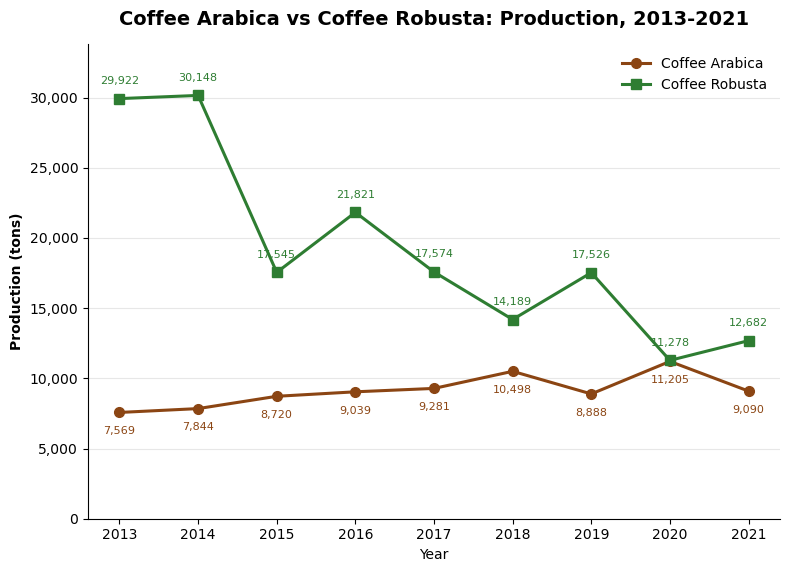

In [17]:
m = METRICS["production_tons"]
plot_metric(coffee, "production_tons", m["title"], m["ylabel"], m["file"])

## 5. Farm Gate Price

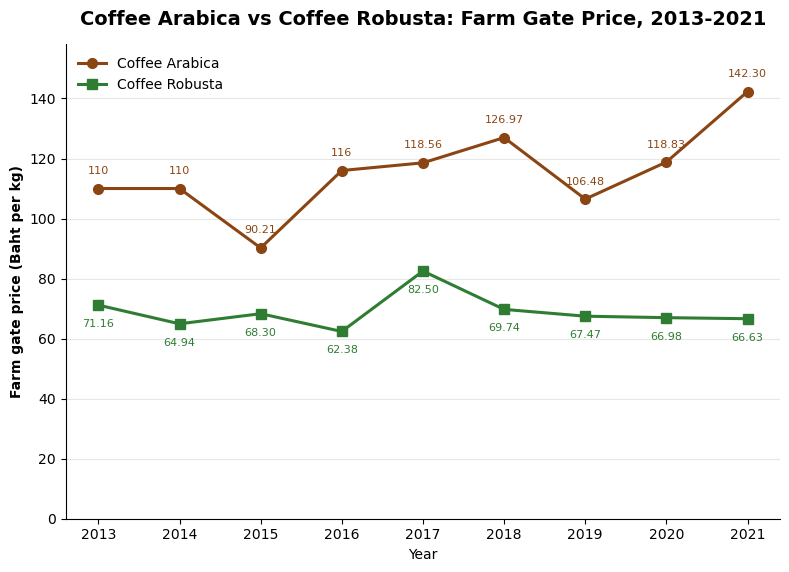

In [18]:
m = METRICS["farm_gate_price_baht_per_kg"]
plot_metric(coffee, "farm_gate_price_baht_per_kg", m["title"], m["ylabel"], m["file"])

## 6. Planted Area

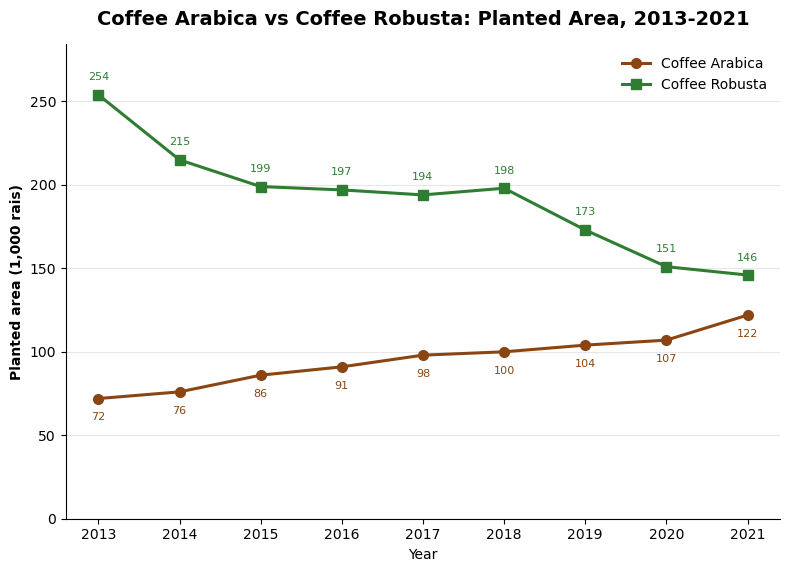

In [19]:
m = METRICS["planted_area_1000_rai"]
plot_metric(coffee, "planted_area_1000_rai", m["title"], m["ylabel"], m["file"])

## 7. Value of Production

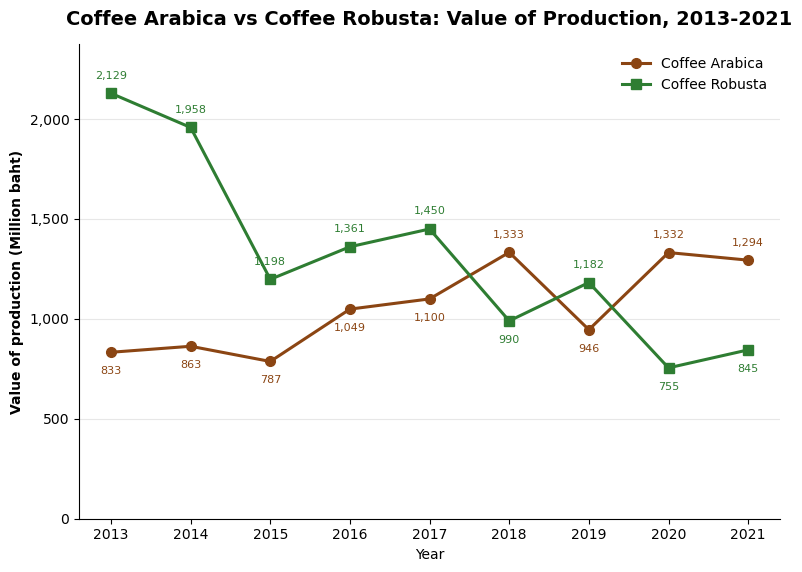

In [20]:
m = METRICS["value_of_production_million_baht"]
plot_metric(coffee, "value_of_production_million_baht", m["title"], m["ylabel"], m["file"])